In [22]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
import get_cpt
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#------------------------------------------------------------
# Compiling Data for Fig. S7: Projected Great Plains
# Precipitation
#------------------------------------------------------------

#------------------------------------------
# Bootstrap UKESM1.1 MH Precipitation
#------------------------------------------

mhData = um.importUMData(f"../Data/Timeseries/MH/pr_197001-204912.nc") * (24 * (60**2) * 30)
piData = um.importUMData(f"../Data/Timeseries/PI/pr_187001-194912.nc") * (24 * (60**2) * 30)

GP_mask = umplt.umRegionMask("GP", mhData.longitude, mhData.latitude)

gp_mhData = mhData.where(GP_mask).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
gp_piData = piData.where(GP_mask).mean(dim=["latitude", "longitude"]).coarsen(time=12).construct(time=["year", "month"])
uk_pr_mon_mean, pr_ci_upper, pr_ci_lower = um.bootstrap_years_anom(gp_piData, gp_mhData)

#------------------------------------------
# PMIP4 MH Precipitation
#------------------------------------------

PMIP4_means = um.importUMData(f"../Data/Monthly_Means/PMIP4_Ensemble.nc")
GP_mask = umplt.umRegionMask("GP", PMIP4_means.longitude, PMIP4_means.latitude)

pmip4_pr_mon_mean = PMIP4_means["mh_pr"].where(GP_mask).mean(dim=["latitude", "longitude"]) - PMIP4_means["pi_pr"].where(GP_mask).mean(dim=["latitude", "longitude"])

#------------------------------------------
# Projected SSP Precipitation
#------------------------------------------

ssp_anoms = pd.read_excel("../Data/GP_pr_ssp_anoms.xlsx")


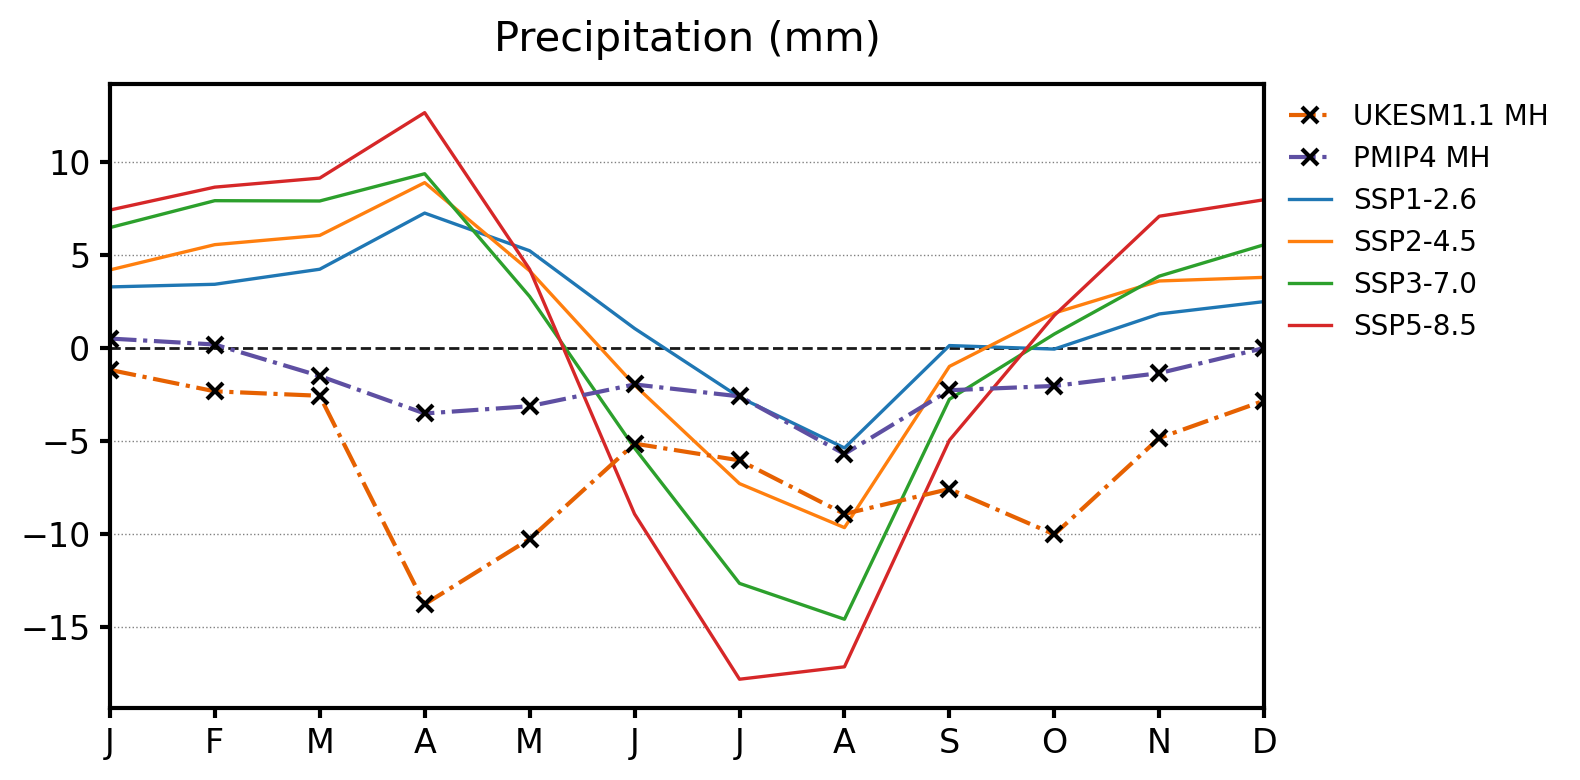

In [ ]:
#------------------------------------------------------------
# Fig. S7: Seasonal cycle of projected precipitation
# anomalies over the Great Plains
#------------------------------------------------------------

fig = plt.figure(figsize=(8, 4), dpi=200)

plot_time = np.arange(12)
colors = ["#E66101", "#5E4FA2"]
title = "Precipitation (mm)"
xticklabs = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

ax = plt.subplot()

ax.plot(plot_time, uk_pr_mon_mean, lw=1.5, ls="dashdot", color="#E66101", marker="x", mew=1.5, mec="black", zorder=10, label="UKESM1.1 MH")

ax.plot(plot_time, pmip4_pr_mon_mean, lw=1.5, ls="dashdot", color="#5E4FA2", marker="x", mew=1.5, mec="black", zorder=10, label="PMIP4 MH")

ssp_exps = ["ssp126", "ssp245", "ssp370", "ssp585"]
labels = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]

for i, exp in enumerate(ssp_exps):
    ssp_pr_mon_mean = (
        ssp_anoms[ssp_anoms["scenario"] == exp]
        .sort_values("month")
        .groupby("month", sort=True)[ssp_anoms.columns.difference(["scenario", "month"])]
        .mean().mean(axis=1).to_numpy()
    )

    ax.plot(plot_time, ssp_pr_mon_mean, lw=1.2, ls="solid", zorder=5, label=labels[i])

ax.grid(True, which="major", axis="y", ls="dotted", color="black", alpha=0.5, lw=0.5, zorder=3)

yticks = ax.get_yticks()
gridlines = ax.yaxis.get_gridlines()
for ytick, gl in zip(yticks, gridlines):
    if np.isclose(ytick, 0.0, atol=1e-8):
        gl.set_visible(False)
        break

ax.axhline(0, ls="dashed", color="black", alpha=0.9, lw=1, zorder=4)

ax.set_xticks(np.arange(0,12), labels=xticklabs,fontsize=12)
ax.set_xlim(min(plot_time), max(plot_time))
ax.tick_params("both", width=1.5)
ax.tick_params(axis="y", labelsize=12)
if i == 0:
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}'))

ax.set_title(title, fontsize=15, pad=12)

ax.spines[["top", "bottom", "right", "left"]].set_linewidth(1.5)
ax.spines[["top", "bottom", "right", "left"]].set_zorder(300)

ax.legend(loc="upper left", bbox_to_anchor=(1, 1.01), frameon=False, handlelength=1.5)

plt.tight_layout()
plt.show()

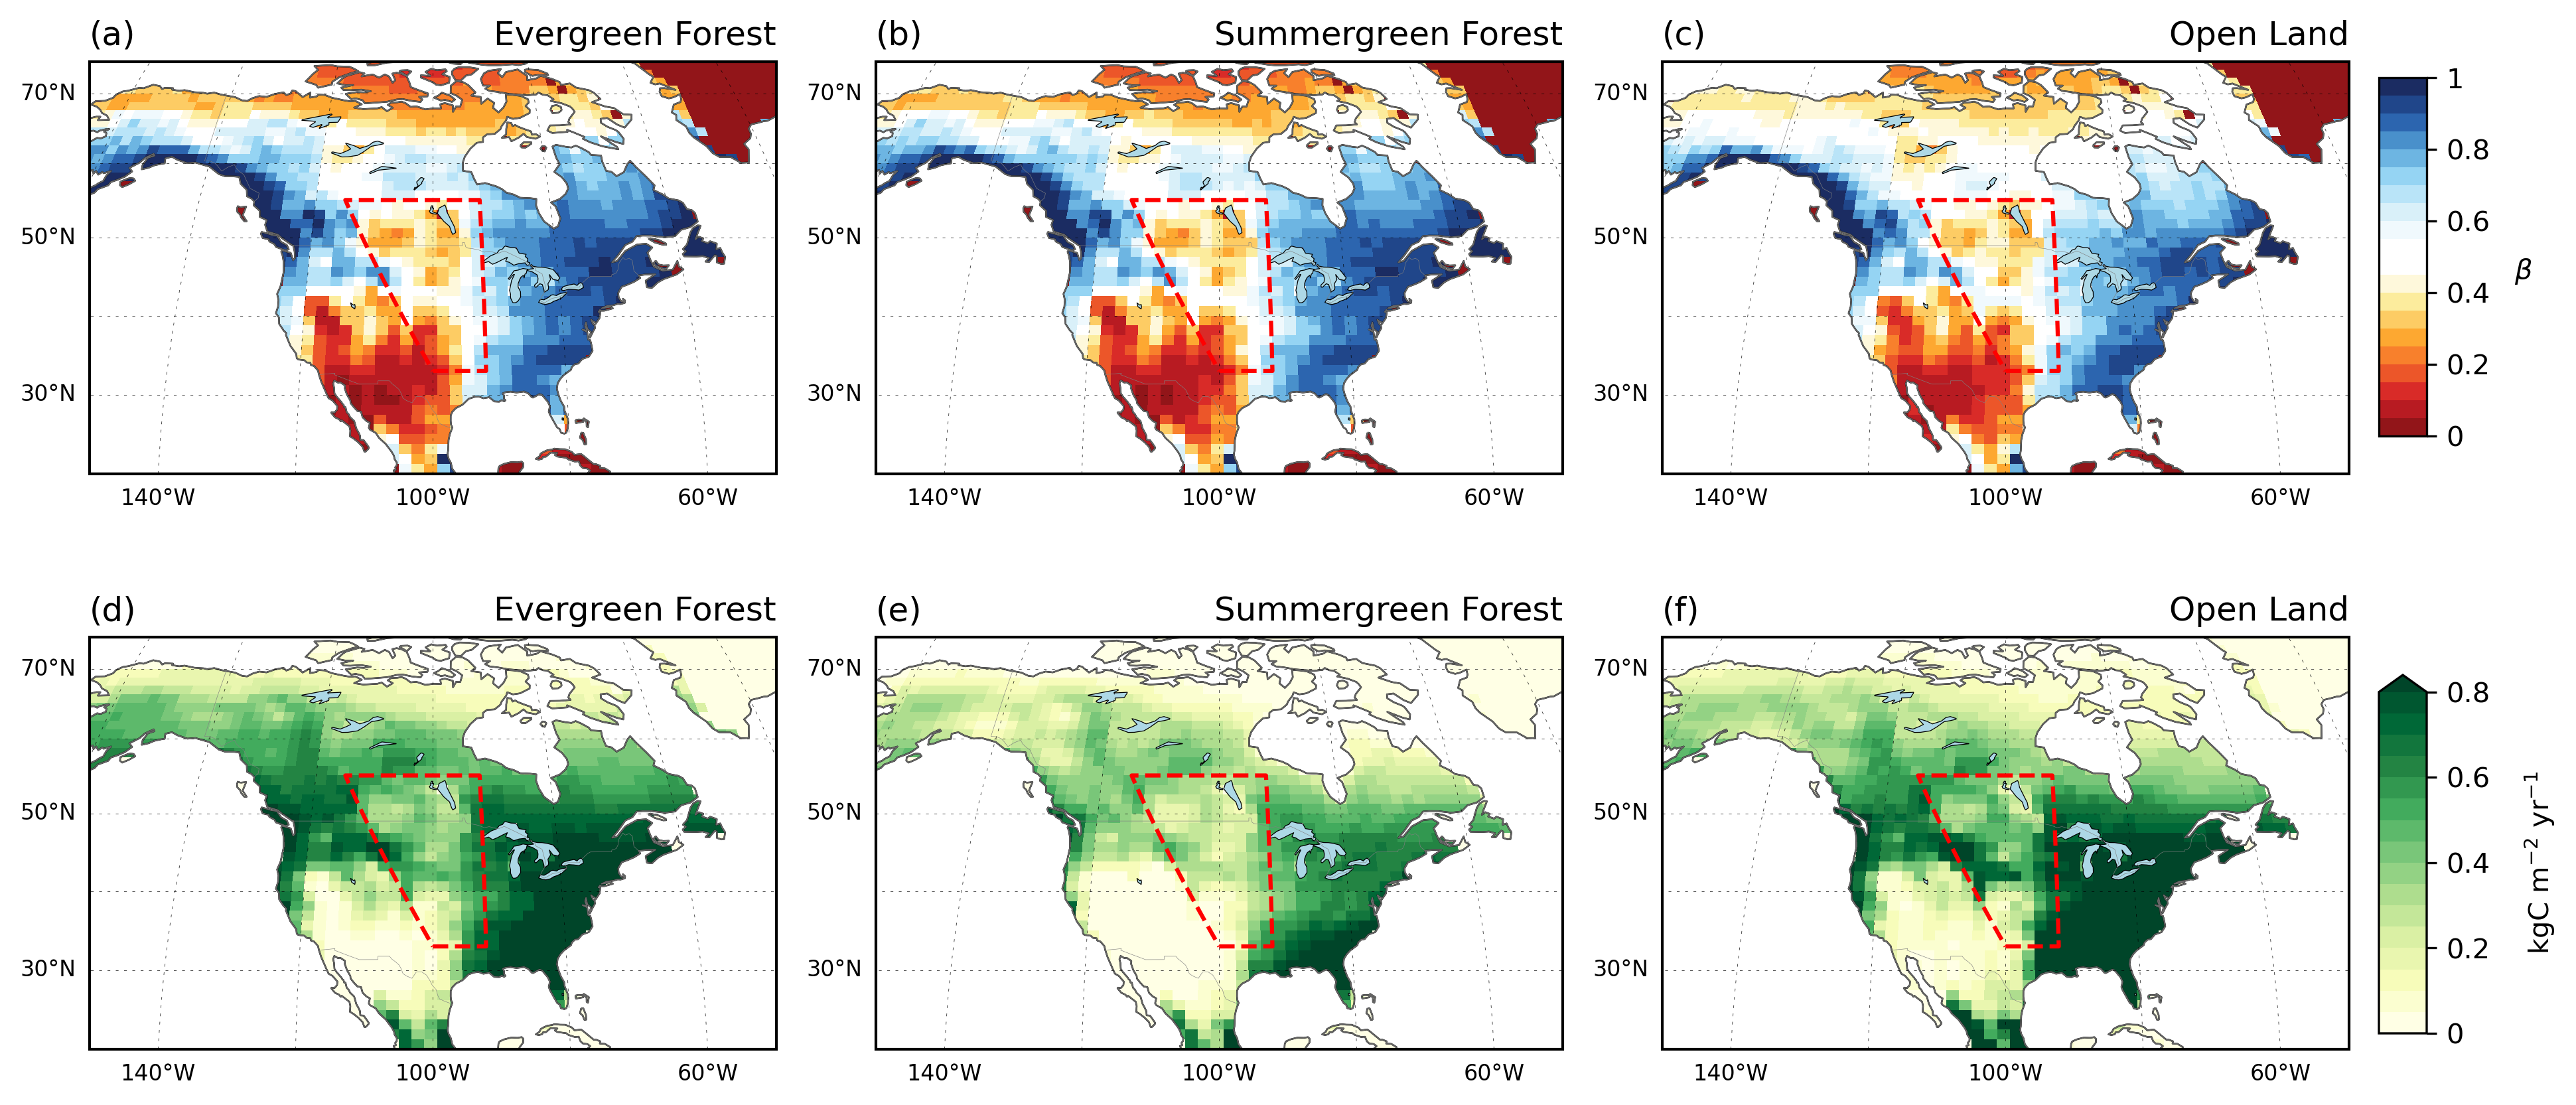

In [ ]:
#------------------------------------------------------------
# Fig. S8: Pre-Industrial moisture stress and NPP
#------------------------------------------------------------

PI_means = um.importUMData(f"../Data/Monthly_Means/PI_monthly_means_187001-194912.nc")

GP_region = umplt.umRegion("GP")

label = np.array([["a", "b", "c"],
                  [ "d", "e", "f"]])
pfts = {
    "Evergreen Forest": [1, 2, 4, 12],
    "Summergreen Forest": [0, 3, 11],
    "Open Land": [5, 6, 7, 8, 9, 10],
}

fig = plt.figure(figsize=(12, 6),dpi=300)
gs = gridspec.GridSpec(2, 3)
lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)


for k, var in enumerate(["beta_factor", "npp_nlimit_pft"]):
    if var == "beta_factor":
        cmap = get_cpt.get_cmap("BlueWhiteOrangeRed.cpt",reverse=True); v = 1; levs = np.linspace(0, v, 21)
        norm = BoundaryNorm(levs, cmap.N)
        cbaxes_loc = (1, 0.6, 0.02, 0.3); cbar_lab = r"$\beta$"; cbar_ticks = np.linspace(0, v, 6)
        
    elif var == "npp_nlimit_pft":
        cmap = cm.YlGn; v = 0.8; levs = np.linspace(0, v, 17)
        norm = BoundaryNorm(levs, cmap.N, extend="max")
        cbaxes_loc = (1, 0.1, 0.02, 0.3); cbar_lab = r"kgC $\mathregular{m^{-2}\ yr^{-1}}$"; cbar_ticks = np.linspace(0, v, 5)
    
    plotData = PI_means[var].mean(dim="time")            

    for i, (pft, tiles) in enumerate(pfts.items()):
        ax = plt.subplot(gs[k, i], projection=proj)
        umplt.plotBaseMap(ax, lims, coastlw=0.6, ocean=True, oceancol="white", lakes=True, lakecol="lightblue")

        p1 = ax.pcolormesh(plotData.longitude, plotData.latitude, plotData.isel(PFTs=tiles).mean(dim="PFTs"), 
                            cmap=cmap, norm=norm, transform=ccrs.PlateCarree(), zorder=0)
        umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70], 
                    xlines=[-40, -80, -120, -160], ylines=[40, 60], labelsize=8, lw=0.2)

        ax.set_title(pft, loc="right")
        ax.set_title(f"({label[k, i]})", loc="left")

        GP_region.plot(ax=ax, add_label=False, line_kws={"linestyle":"dashed","color":"red"})

    cbaxes = fig.add_axes(cbaxes_loc)
    cbar = plt.colorbar(p1, orientation="vertical", cax=cbaxes, ticks=cbar_ticks)
    cbar.ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:g}')) 
    cbar.ax.minorticks_off() 
    if var == "beta_factor":
        cbar.set_label(label=cbar_lab, rotation=0, labelpad=12)
    elif var == "npp_nlimit_pft":
        cbar.set_label(label=cbar_lab, labelpad=12)

plt.tight_layout()
plt.show()

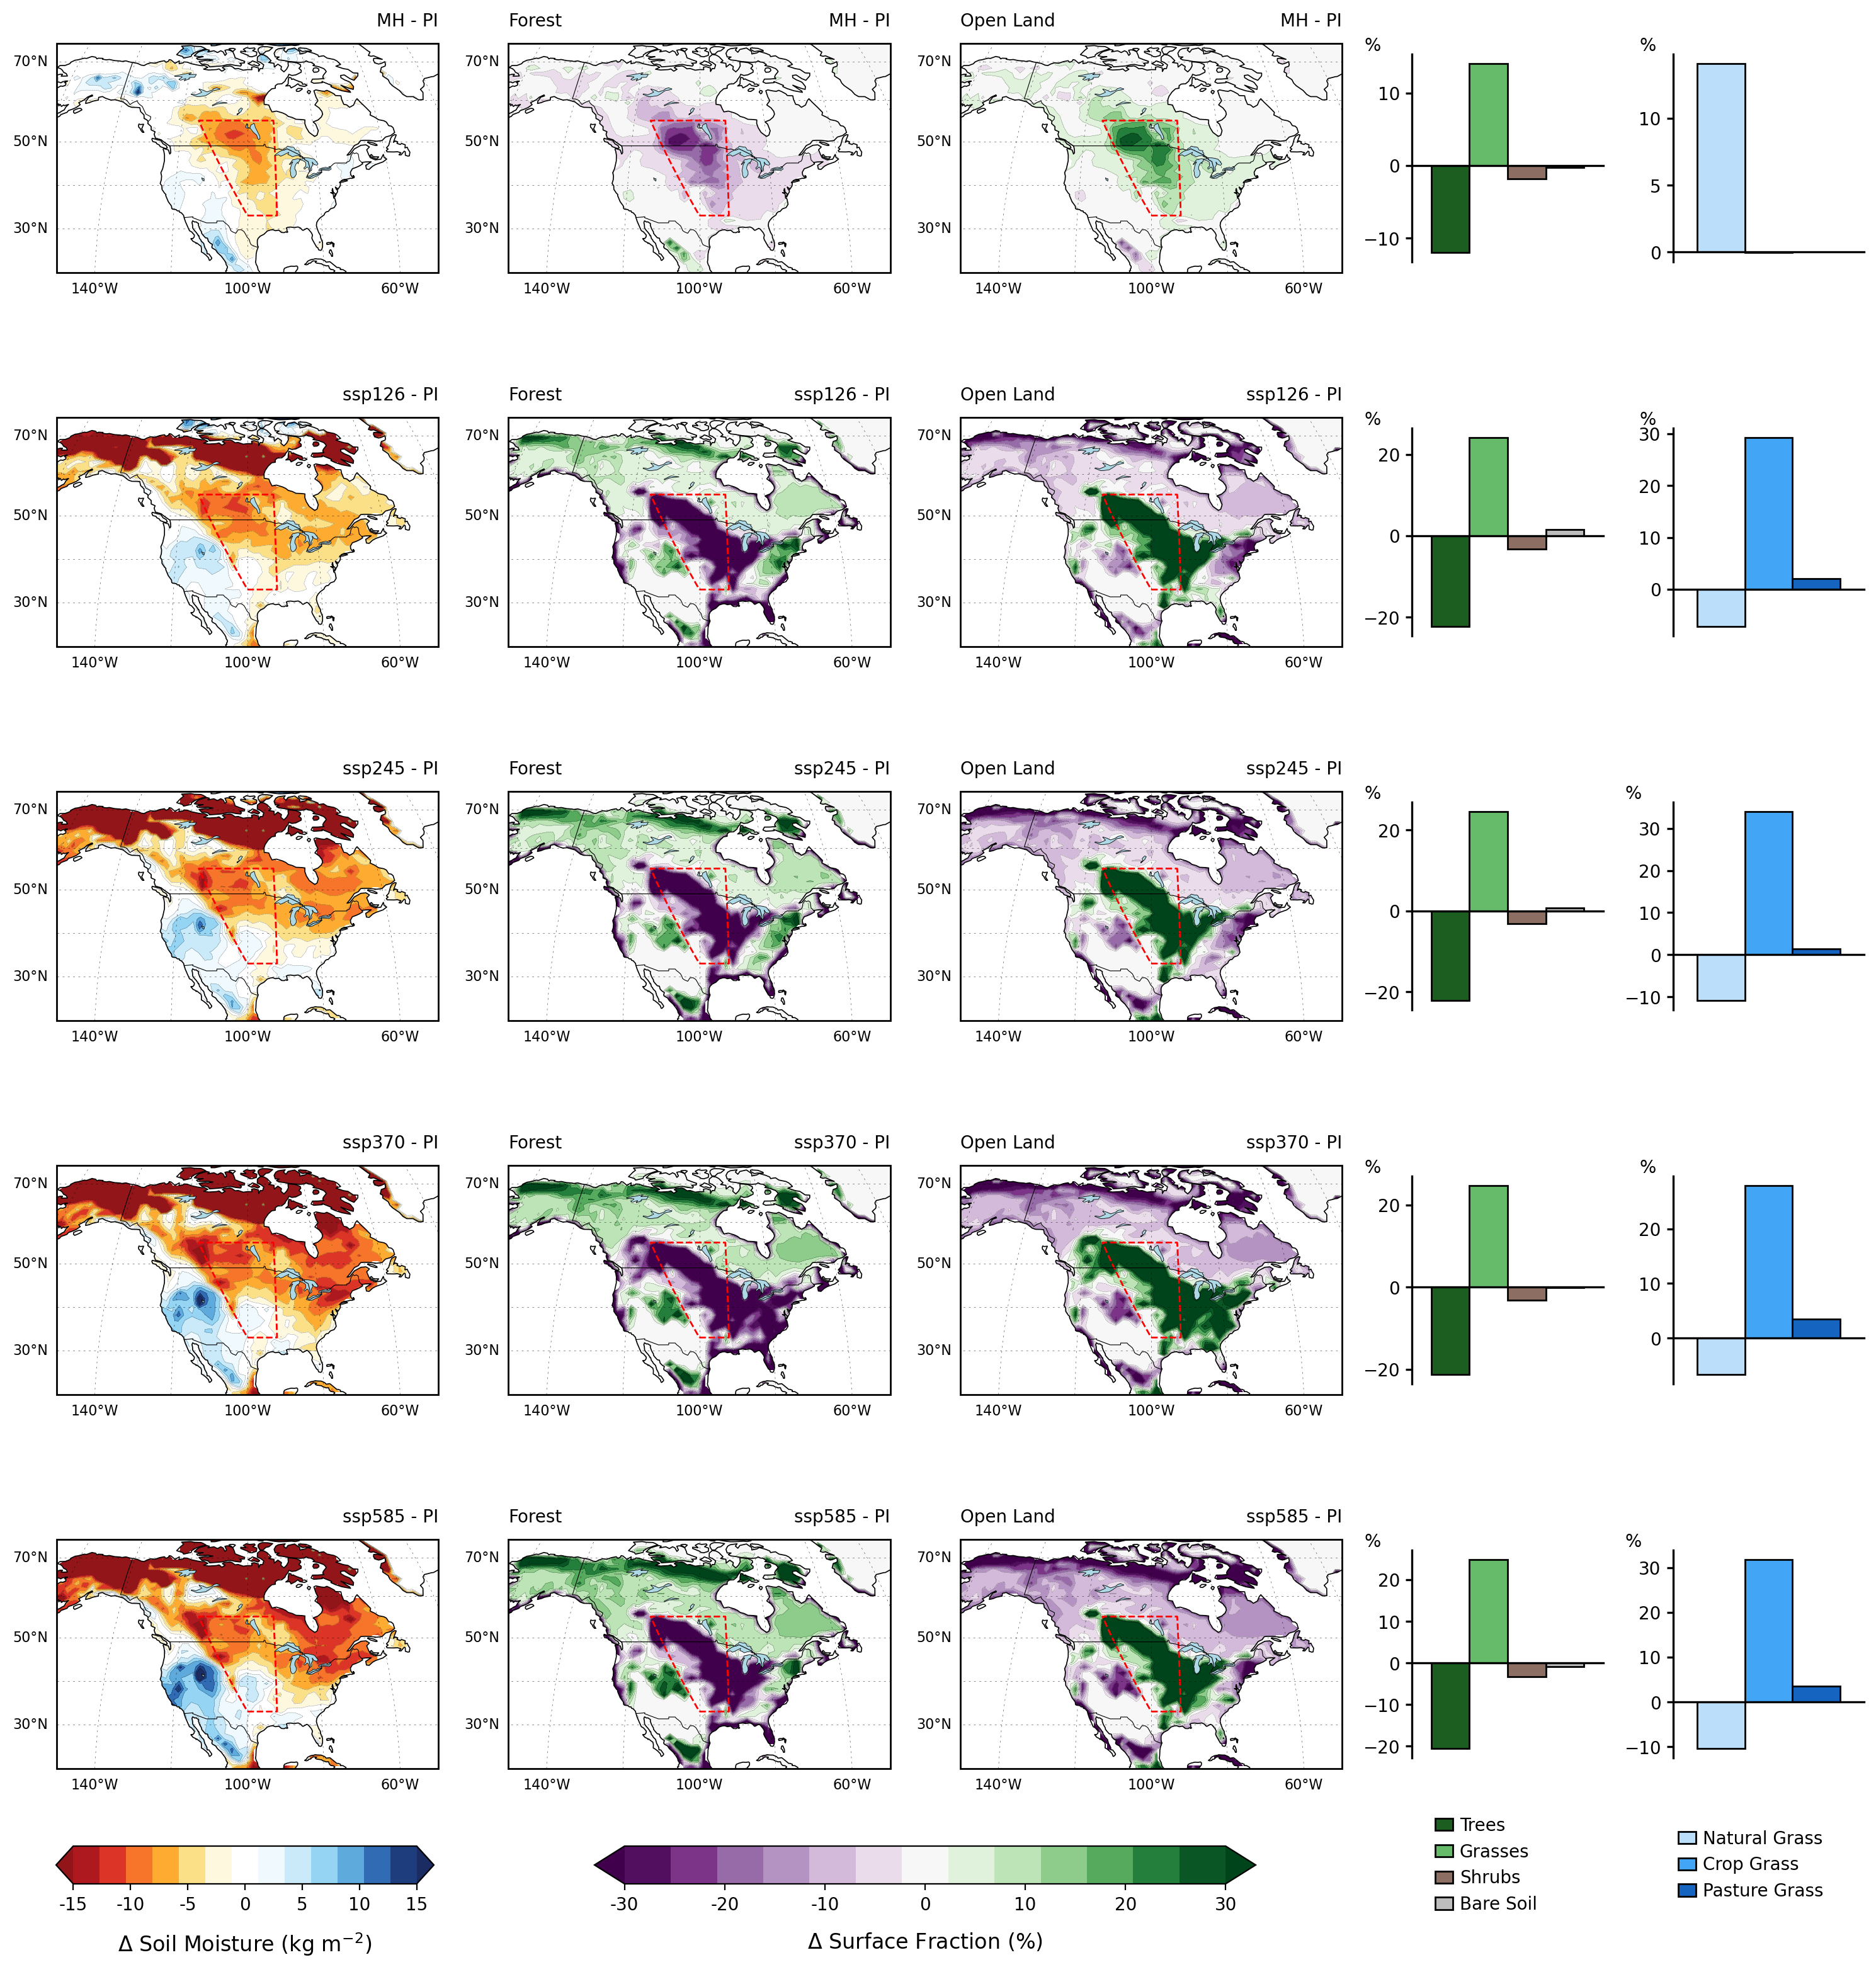

In [23]:
#------------------------------------------------------------
# Fig. S9: Projected soil moisture and vegetation under
# SSPs
#------------------------------------------------------------

PI = um.importUMData(f"../Data/Monthly_Means/PI_monthly_means_187001-194912.nc")
MH = um.importUMData(f"../Data/Monthly_Means/MH_monthly_means_197001-204912.nc")

#------------------------------------------------------------
# Figure Properties
#------------------------------------------------------------

fig = plt.figure(figsize=(15, 15), dpi=200)
gs = gridspec.GridSpec(5, 5, width_ratios=[2, 2, 2, 1, 1])

lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)
cmap_sm = get_cpt.get_cmap("BlueWhiteOrangeRed.cpt", reverse=True); v_sm = 15; levs_sm = np.linspace(-v_sm, v_sm, 14); cbar_lab_sm = r"$\Delta$ Soil Moisture (kg $\mathregular{m^{-2}}$)"
cmap_frac = cm.PRGn; v_frac = 30; levs_frac = np.linspace(-v_frac, v_frac, 14); cbar_lab_frac = r"$\Delta$ Surface Fraction (%)"

pft_colors   = ["#1B5E20", "#66BB6A", "#8D6E63", "#BDBDBD"]
grass_colors = ["#BBDEFB", "#42A5F5", "#1565C0"]

LON, LAT = np.meshgrid(PI.longitude, PI.latitude)
GP_mask = umplt.umRegionMask("GP", PI.longitude, PI.latitude)
GP_region = umplt.umRegion("GP")

#------------------------------------------------------------
# Definitions of SSPs, surface types and biomes
# Relationships between Biomes/Grass Types and UKESM tiles/
# SSP surface types
#------------------------------------------------------------

experiments = ["MH", "ssp126", "ssp245", "ssp370", "ssp585"]
surface_types = [
    "baresoilFrac", "grassFracC3", "grassFracC4", "shrubFrac",
    "treeFracBdlDcd", "treeFracBdlEvg", "treeFracNdlDcd", "treeFracNdlEvg",
    "cropFracC3", "cropFracC4", "pastureFracC3", "pastureFracC4"
]
biomes = ["Forest", "Open Land"]

TILES_ALL = {
    "Trees": [0, 1, 2, 3, 4],
    "Grasses": [5, 6, 7, 8, 9, 10],
    "Shrubs": [11, 12],
    "Bare Soil": [-1]
}
TILES_GRASS = {
    "Natural": [5, 8],
    "Crop": [6, 9],
    "Pasture": [7, 10]
}

SSP_ALL = {
    "Trees": ["treeFracBdlDcd", "treeFracBdlEvg", "treeFracNdlDcd", "treeFracNdlEvg"],
    "Grasses": ["grassFracC3", "grassFracC4", "cropFracC3", "cropFracC4", "pastureFracC3", "pastureFracC4"],
    "Shrubs": ["shrubFrac"],
    "Bare Soil": ["baresoilFrac"],
}
SSP_GRASS = {
    "Natural": ["grassFracC3", "grassFracC4"],
    "Crop": ["cropFracC3", "cropFracC4"],
    "Pasture": ["pastureFracC3", "pastureFracC4"],
}

BIOME_TILES = {
    "Forest": [0, 1, 2, 3, 4, 11, 12],
    "Open Land": [5, 6, 7, 8, 9, 10, -1],
}
SSP_BIOME = {
    "Forest": ["shrubFrac", "treeFracBdlDcd", "treeFracBdlEvg", "treeFracNdlDcd", "treeFracNdlEvg"],
    "Open Land": ["grassFracC3", "grassFracC4", "cropFracC3", "cropFracC4", "pastureFracC3", "pastureFracC4", "baresoilFrac"],
}

#------------------------------------------------------------
# Supporting functions
#------------------------------------------------------------

def gp_mean(da, mask):
    return da.where(mask).mean().item()

def tile_group_means(sfrac_tmean, groups, mask):
    return np.array([
        gp_mean(sfrac_tmean.isel(surface_tiles=tiles).sum("surface_tiles", min_count=1), mask)
        for _, tiles in groups.items()
    ])

def var_group_means(ds_tmean, groups, mask):
    out = []
    for _, vars_ in groups.items():
        da = ds_tmean[vars_].to_array("v").sum("v")
        out.append(gp_mean(da, mask))

    return np.array(out)

#------------------------------------------------------------
# Compiling Surface Fraction / Grass Data
#------------------------------------------------------------

PI_tmean = PI["surfacefrac"].mean("time") * 100
MH_tmean = MH["surfacefrac"].mean("time") * 100

ssp_fracs_tmean = {}
for scenario in experiments[1:]:
    das = []
    for pft in surface_types:
        da = um.importUMData(
            f"../../scenario_fracs/{scenario}/{pft}_UKESM1-0-LL_{scenario}_201501-210012.nc"
        ).isel(time=slice(-240, None)).mean("time")
        das.append(da)
    ssp_fracs_tmean[scenario] = xr.merge(das)

PI_fracs = tile_group_means(PI_tmean, TILES_ALL, GP_mask)
PI_grass_fracs = tile_group_means(PI_tmean, TILES_GRASS, GP_mask)

GP_fracs = {"MH": tile_group_means(MH_tmean, TILES_ALL, GP_mask)}
Grass_fracs = {"MH": tile_group_means(MH_tmean, TILES_GRASS, GP_mask)}

for exp in experiments[1:]:
    GP_fracs[exp] = var_group_means(ssp_fracs_tmean[exp], SSP_ALL, GP_mask)
    Grass_fracs[exp] = var_group_means(ssp_fracs_tmean[exp], SSP_GRASS, GP_mask)

PI_biome = {
    biome: PI_tmean.isel(surface_tiles=tiles).sum("surface_tiles", min_count=1)
    for biome, tiles in BIOME_TILES.items()
}
MH_biome = {
    biome: MH_tmean.isel(surface_tiles=tiles).sum("surface_tiles", min_count=1)
    for biome, tiles in BIOME_TILES.items()
}
SSP_biome = {
    exp: {biome: ssp_fracs_tmean[exp][vars_].to_array("v").sum("v") for biome, vars_ in SSP_BIOME.items()}
    for exp in experiments[1:]
}

#------------------------------------------------------------
# Compiling Soil Moisture Data
#------------------------------------------------------------

PI_mrso = PI["soil_moisture"].isel(depth=[0, 1]).mean(dim="time").sum(dim="depth", min_count=1)
MH_mrso = MH["soil_moisture"].isel(depth=[0, 1]).mean(dim="time").sum(dim="depth", min_count=1)

SSP_mrso = {
    exp: um.importUMData(
        f"../../scenario_fracs/{exp}/mrsol_UKESM1-0-LL_{exp}_201501-210012.nc"
    ).isel(time=slice(-240, None), depth=[0, 1]).mean("time").sum("depth", min_count=1)
    for exp in experiments[1:]
}

#------------------------------------------------------------
# Plot Figure
#------------------------------------------------------------

for i, exp in enumerate(experiments):
    if exp == "MH":
        exp_biome = MH_biome
        exp_mrso = MH_mrso
    else:
        exp_biome = SSP_biome[exp]
        exp_mrso = SSP_mrso[exp]

    ax = plt.subplot(gs[i, 0], projection=proj)
    umplt.plotBaseMap(ax, lims, coastlw=0.6, ocean=True, oceancol="white", bordercol="black", borderlw=0.4)
    ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue", linewidth=0.3, zorder=1)
    umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70], xlines=[-40, -80, -120, -160], ylines=[40, 60],
                    labelsize=8, lw=0.2)
    
    mrso_anom = exp_mrso - PI_mrso

    cf1 = ax.contourf(LON, LAT, mrso_anom.data, extend="both", cmap=cmap_sm, levels=levs_sm, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
    ax.contour(LON, LAT, mrso_anom.data, extend="both", colors="black", levels=levs_sm, linestyles="dashed", linewidths=0.1, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

    GP_region.plot(ax=ax, line_kws={"color": "red", "linestyle": "dashed", "linewidth": 1, "zorder": 0}, add_coastlines=False, add_label=False)

    ax.set_title(f"{exp} - PI", loc="right", fontsize=10, pad=10)  

    for j, biome in enumerate(biomes, start=1):
        ax = plt.subplot(gs[i, j], projection=proj)
        umplt.plotBaseMap(ax, lims, coastlw=0.6, ocean=True, oceancol="white", bordercol="black", borderlw=0.4)
        ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue", linewidth=0.3, zorder=1)
        umplt.plotGrid(ax, xlabeledlines=[-60, -100, -140], ylabeledlines=[30, 50, 70], xlines=[-40, -80, -120, -160], ylines=[40, 60],
                       labelsize=8, lw=0.2)
        
        sfrac_anom = exp_biome[biome] - PI_biome[biome]

        cf2 = ax.contourf(LON, LAT, sfrac_anom.data, extend="both", cmap=cmap_frac, levels=levs_frac, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
        ax.contour(LON, LAT, sfrac_anom.data, extend="both", colors="black", levels=levs_frac, linestyles="dashed", linewidths=0.1, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)

        GP_region.plot(ax=ax, line_kws={"color": "red", "linestyle": "dashed", "linewidth": 1, "zorder": 0}, add_coastlines=False, add_label=False)

        ax.set_title(f"{biome}", loc="left", fontsize=10, pad=10)
        ax.set_title(f"{exp} - PI", loc="right", fontsize=10, pad=10)       

    bar_specs = [
        ("ALL", GP_fracs[exp] - PI_fracs, pft_colors),
        ("GRASS", Grass_fracs[exp] - PI_grass_fracs, grass_colors)
    ]

    for k, (name, plotData, colors) in enumerate(bar_specs, start=3):
        xpos = np.arange(len(plotData))

        ax = plt.subplot(gs[i, k])
        ax.bar(xpos, plotData, width=1, color=colors, edgecolor="black", linewidth=1)

        ax.spines["bottom"].set_position(("data", 0))
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_xlim(xpos[0] - 1, xpos[-1] + 1)
        ax.tick_params(axis="x", bottom=False, labelbottom=False)
        ax.tick_params(axis="y", width=1.2)
        ax.spines[["left", "bottom"]].set_linewidth(1.2)
        ax.set_ylabel("%", rotation=0, loc="top", labelpad=-10)

plt.tight_layout()

for ax in fig.get_axes():
    try: ss = ax.get_subplotspec()
    except Exception: continue
    if ss is not None and ss.colspan.start in (3, 4):
        umplt.ax_adjust(ax, shrinky=0.6)

cbaxes = fig.add_axes((0.033, -0.02, 0.2, 0.02))
cbar = plt.colorbar(cf1, extend='both', orientation='horizontal', ticks=np.linspace(-v_sm, v_sm, 7), cax=cbaxes)
cbar.ax.tick_params(labelsize=10) 
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d')) 
cbar.set_label(label=cbar_lab_sm, size=12, labelpad=10)

cbaxes = fig.add_axes((0.318, -0.02, 0.35, 0.02))
cbar = plt.colorbar(cf2, extend='both', orientation='horizontal', ticks=np.linspace(-v_frac, v_frac, 7), cax=cbaxes)
cbar.ax.tick_params(labelsize=10) 
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d')) 
cbar.set_label(label=cbar_lab_frac, size=12, labelpad=10)

lgaxes = fig.add_axes((0.74, -0.06, 0.1, 0.1))
labels = ["Trees", "Grasses", "Shrubs", "Bare Soil"]
patches_list = [Patch(facecolor=c, label=l, edgecolor="black", linewidth=1) for c, l in zip(pft_colors, labels)]
lgaxes.legend(handles=patches_list, frameon=False,
        loc='center', handlelength=1.0, handletextpad=0.4, fontsize=10)
lgaxes.set_axis_off()

lgaxes = fig.add_axes((0.88, -0.06, 0.1, 0.1))
labels = ["Natural Grass", "Crop Grass", "Pasture Grass"]
patches_list = [Patch(facecolor=c, label=l, edgecolor="black", linewidth=1) for c, l in zip(grass_colors, labels)]
lgaxes.legend(handles=patches_list, frameon=False,
        loc='center', handlelength=1.0, handletextpad=0.4, fontsize=10)
lgaxes.set_axis_off()

plt.show()
